# Análisis de Datos Exploratorio (EDA)

## Descripción del dataset

El dataset escogido es de Kaggle y es sobre precios de casas.

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from plotnine import *
from src.get_data import get_data

# get the data from kagglehub
df = get_data()

# get data summary
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            4600 non-null   str    
 1   price           4600 non-null   float64
 2   bedrooms        4600 non-null   float64
 3   bathrooms       4600 non-null   float64
 4   sqft_living     4600 non-null   int64  
 5   sqft_lot        4600 non-null   int64  
 6   floors          4600 non-null   float64
 7   waterfront      4600 non-null   int64  
 8   view            4600 non-null   int64  
 9   condition       4600 non-null   int64  
 10  sqft_above      4600 non-null   int64  
 11  sqft_basement   4600 non-null   int64  
 12  yr_built        4600 non-null   int64  
 13  yr_renovated    4600 non-null   int64  
 14  street          4600 non-null   str    
 15  city            4600 non-null   str    
 16  statezip        4600 non-null   str    
 17  price_per_sqft  4600 non-null   float64
dtyp

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price_per_sqft
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261,265.876209
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536,357.503362
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000,180.817500
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000,243.855000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000,314.840000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000,22533.900000


Contiene 4600 entradas y 18 variables, las cuales son cuantitativas a excepción del nombre de la calle, el nombre de la ciudad y el zip del estado (las casas se encuentran en EEUU), que son cualitativas nominales. Además también se tiene la fecha en la que se recopiló la entrada.

Entre las variables cuantitativas se tiene el precio, la cantidad de baños, la cantidad de niveles que tiene la casa, los pies cuadrados construidos y del lote, además de los pies cuadrados del primer piso (above) y los pies cuadrados del sótano.

Se tiene también una variable binaria, que es '0' cuando la casa no colinda con algún cuerpo de agua y '1' cuando sí.

Además, se tienen dos variables ordinales, que son la calificación de la vista (donde 1 es la peor y 4 es la mejor) y la calificación de la condición de la propiedad (1 como la peor, 5 como la mejor).

Por último se tiene una variable calculada a partir de otras dos, que es el precio por pies cuadrados.

## Análisis Exploratorio

### Gráfico de Densidad

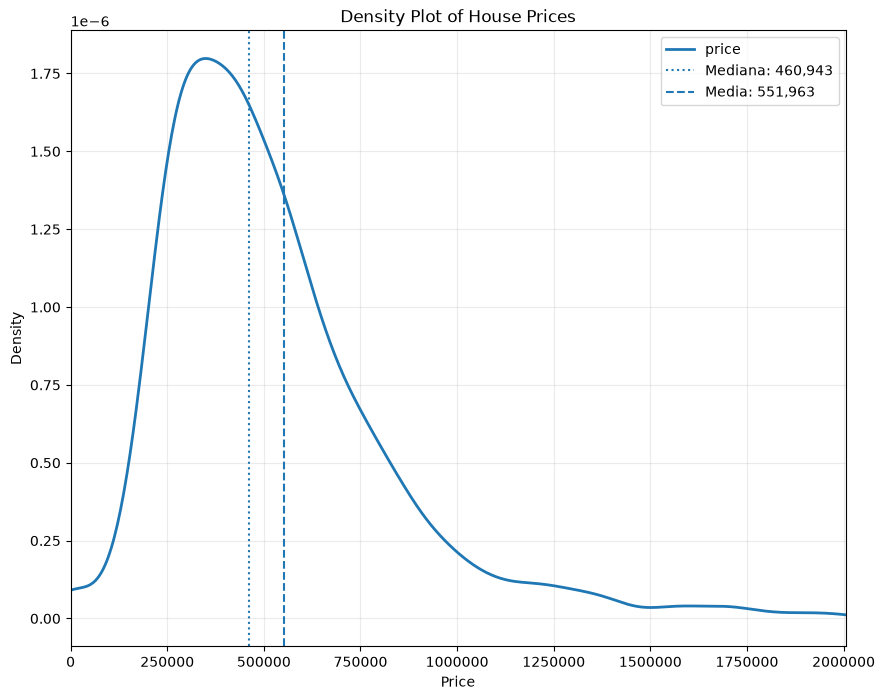

In [23]:
priceData = df['price'].dropna()
priceLimit = priceData.quantile(0.99)

priceDataForPlot = priceData[
    (priceData >= 0) &
    (priceData <= priceLimit)
]

plt.figure(figsize=(10, 8))

priceDataForPlot.plot(
    kind='density',
    linewidth=2
)

plt.axvline(
    priceData.median(),
    linestyle=':',
    label=f"Mediana: {priceData.median():,.0f}"
)

plt.axvline(
    priceData.mean(),
    linestyle='--',
    label=f"Media: {priceData.mean():,.0f}"
)

plt.title('Density Plot of House Prices')
plt.xlabel('Price')
plt.ylabel('Density')
plt.xlim(0, priceLimit)
plt.ticklabel_format(style='plain', axis='x')
plt.legend()
plt.grid(alpha=0.25)

plt.show()

Para este gráfico se analizó la distribución de price (precio) de las viviendas del dataset. El gráfico de densidad permite observar en qué rangos de precio se concentra la mayor cantidad de viviendas y cómo se distribuyen los valores. Debido a la presencia de precios extremadamente altos, se acotó el rango mostrado para facilitar la visualización de la distribución principal, sin eliminar estos datos del dataset.

La mayor concentración de viviendas se encuentra aproximadamente entre los 250 000 y 600 000, con el punto de mayor densidad cercano a los 350 000. Además, la variable price (precio) parece presentar una distribución asimétrica hacia la derecha, con una mayor concentración de viviendas en los rangos de precio bajos y medios y una menor cantidad de viviendas con precios elevados.

La media del precio, aproximadamente 551 963, es mayor que la mediana de 460 943, lo cual apunta a que las viviendas con precios elevados están aumentando el valor promedio. O sea, que hay influencia de estos valores altos.

### Scatterplot: Área habitable vs. precio

Valores faltantes:
sqft_living    0
price          0
dtype: int64
Correlación de Pearson: 0.43


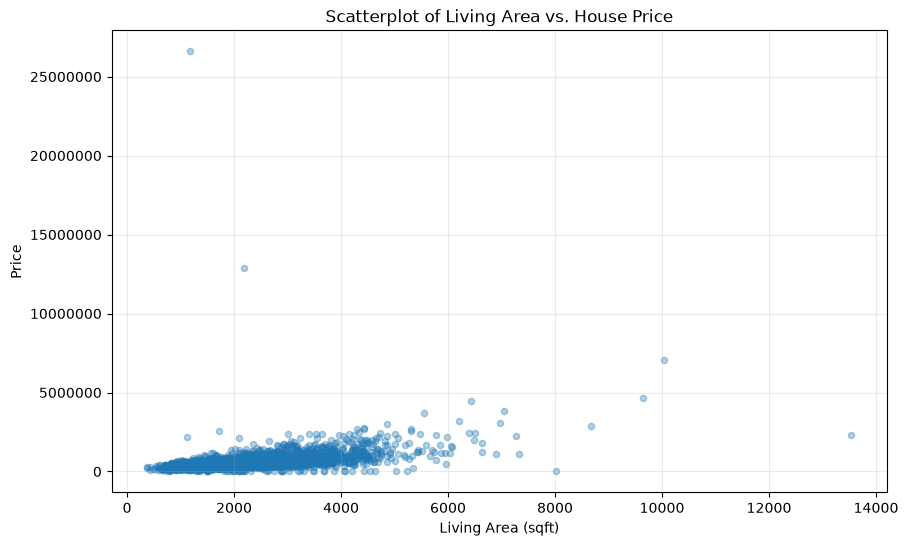

In [17]:
scatterData = df[['sqft_living', 'price']].dropna()

print("Valores faltantes:")
print(df[['sqft_living', 'price']].isna().sum())

priceAreaCorrelation = scatterData['sqft_living'].corr(scatterData['price'])
print(f"Correlación de Pearson: {priceAreaCorrelation:.2f}")

plt.figure(figsize=(10, 6))

plt.scatter(
    scatterData['sqft_living'],
    scatterData['price'],
    alpha=0.35,
    s=20
)

plt.title('Scatterplot of Living Area vs. House Price')
plt.xlabel('Living Area (sqft)')
plt.ylabel('Price')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(alpha=0.25)
plt.show()


Para este gráfico se comparó el área habitable de las viviendas (sqft_living) con su precio (price) con el objetivo de observar si existe una relación entre ambas variables. 

Se observa una tendencia positiva entre sqft_living y price, ya que generalmente las viviendas con mayor área habitable presentan precios más altos. Otra observación es que la dispersión de los puntos aumenta conforme crece el área habitable. Por lo tanto, el área habitable podría considerarse un posible factor de interés para explicar el precio de una vivienda. Sin embargo, la dispersión de los puntos muestra que el área habitable por sí sola no determina el precio, por lo que sería necesario considerar otros factores. Además, los valores extremos deben tomarse en cuenta porque podrían afectar análisis estadísticos posteriores.


### Matriz de Correlación

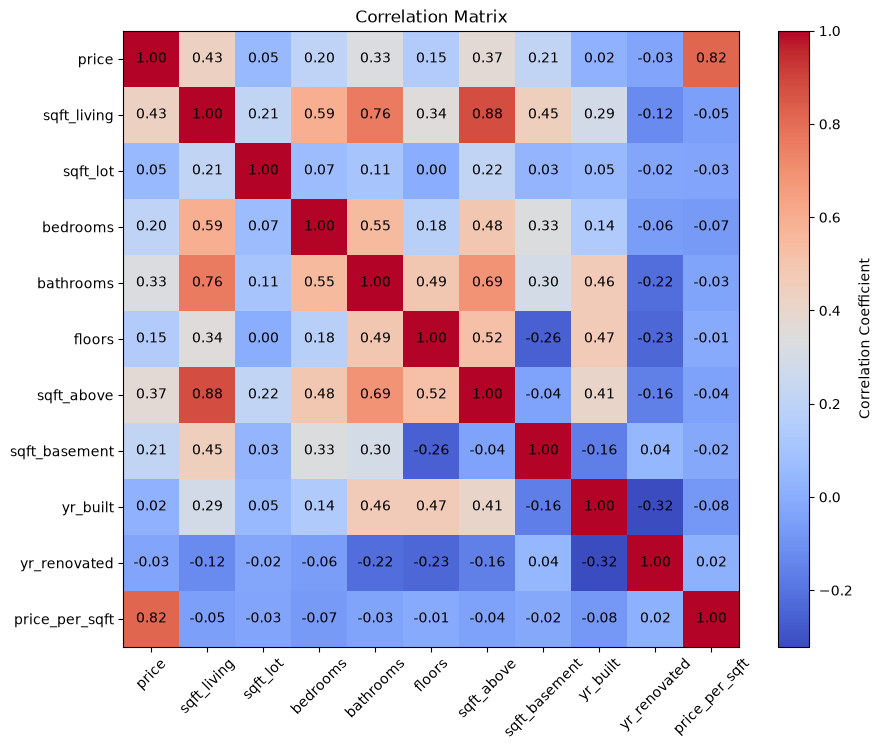

In [18]:
# Correlation matrix
corr_cols = ['price', 'sqft_living', 'sqft_lot', 'bedrooms', 'bathrooms', 'floors', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'price_per_sqft']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlation Coefficient')
plt.title('Correlation Matrix')
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45)
plt.yticks(range(len(corr_cols)), corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va='center', color='black')

plt.show()

En base a las variables númericas del dataset correlacionables, se obtuvo el coeficiente de correlación de Pearson. Cada celda de la matriz representa la de relación entre las variables fila-columna, entre valores de -1 y 1. 

La correlación más alta encontrada es entre sqft_living y sqft_above siendo de 0.88, aunque no es un hallazgo que sorprenda ya que sqft_above es un subconjunto de sqft_living. Sorprendentemente, la correlación entre el precio de los hogares (price) y la cantidad de habitaciones que poseen (bedrooms) es relativamente baja, siendo de 0.20, mostrando que el precio de una vivienda no está justificado por la cantidad de habitaciones. Otra correlación que no acaba justificando el precio de un hogar es el de sqft_living y price_per_sqft, ya que su correlación es casi nula (-0,05). Esto demuestra que el precio por metro cuadrado de una casa no necesariamente se debe al tamaño de esta.

Debería evitarse el uso de sqft_living y sqft_above ya que la información que aportan es poco relevante. Además, características como la cantidad de habitaciones o el tamaño de la vivienda poseen baja correlación con el precio, lo que sugiere que hay otras variables que tengan mayor influencia en ello, como la ubicación.

### Heatmaps

#### Precio promedio por ciudad y condición de vivienda

             city  condition         price
0          Algona          3  2.016100e+05
1          Algona          4  2.300000e+05
2          Auburn          2  3.250000e+05
3          Auburn          3  3.263965e+05
4          Auburn          4  2.568732e+05
..            ...        ...           ...
129   Woodinville          3  6.294968e+05
130   Woodinville          4  5.895204e+05
131   Woodinville          5  5.268000e+05
132  Yarrow Point          3  1.901000e+06
133  Yarrow Point          4  9.594500e+05

[134 rows x 3 columns]


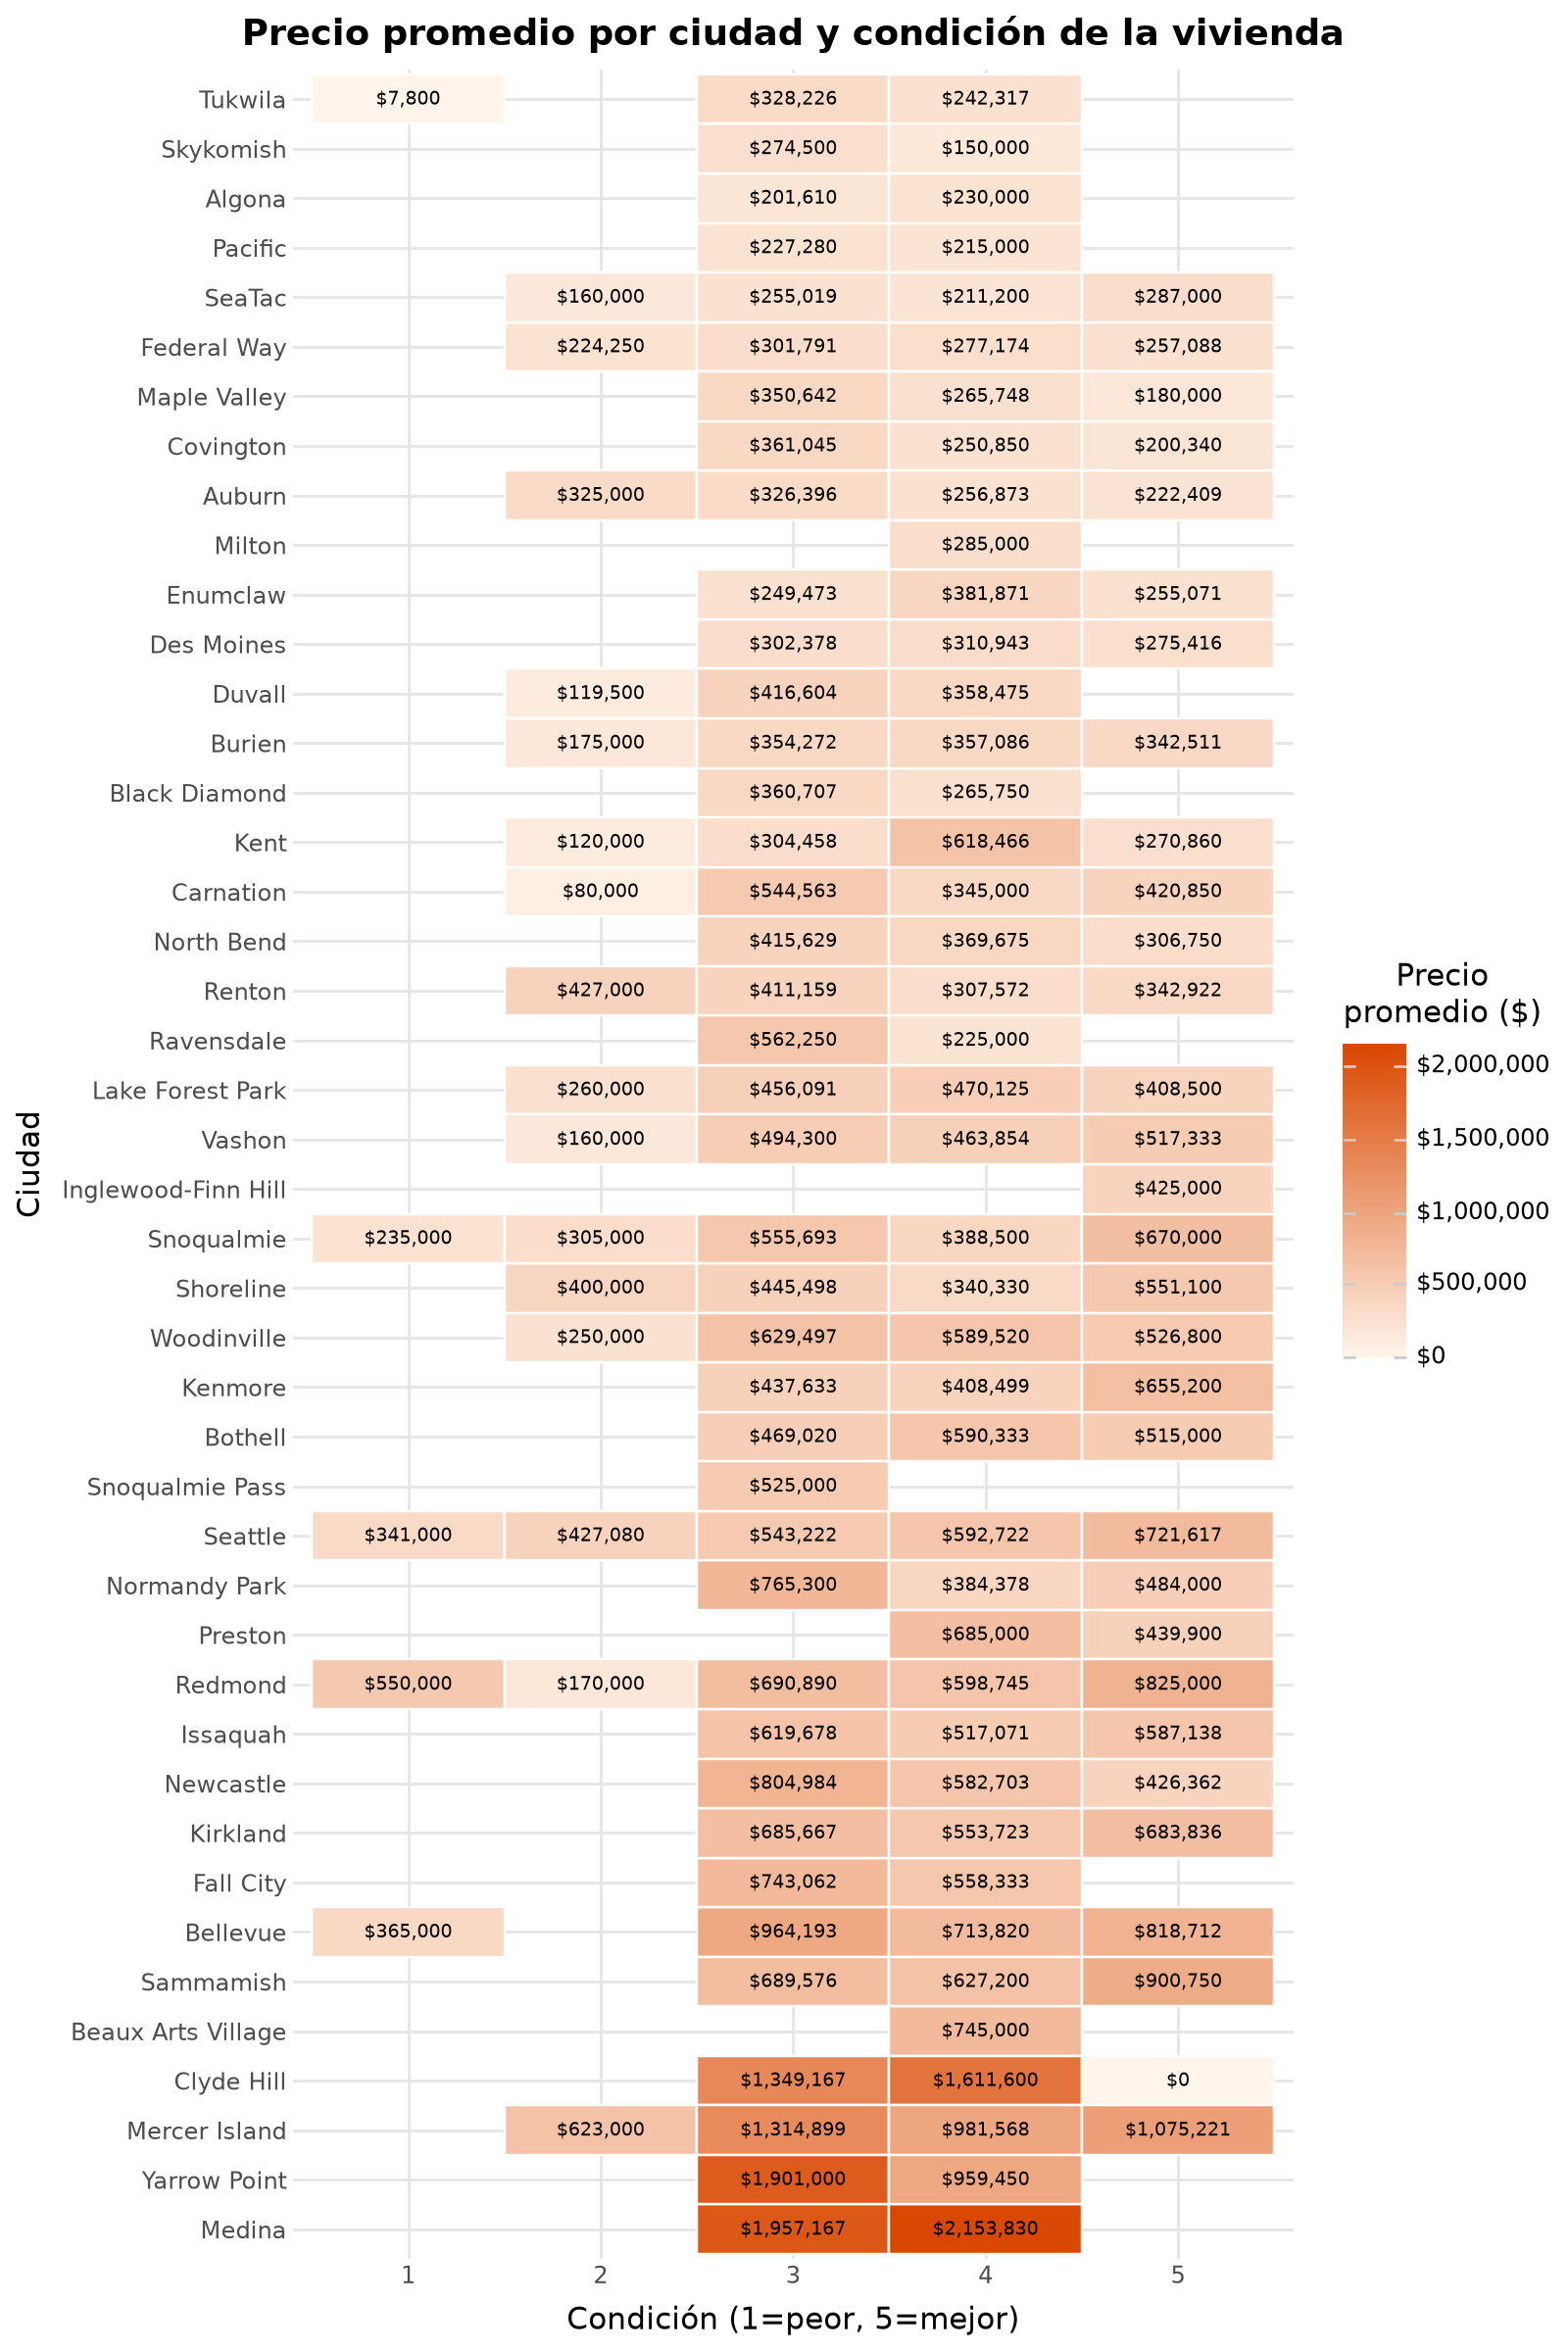

In [19]:
# precio promedio por ciudad y condicion
price_condition = (df.groupby(['city', 'condition'])['price']
                   .mean()
                   .reset_index())
ordered_cities = price_condition.groupby('city')['price'].mean().sort_values(ascending=False).index
price_condition['city'] = pd.Categorical(price_condition['city'], categories=ordered_cities, ordered=True)

print(price_condition)

chart = (
    ggplot(price_condition, aes(x='factor(condition)', y='city', fill='price'))
    + geom_tile(color='white', size=0.5)
    + geom_text(aes(label='price.round(0).astype(int)'), size=7, color='black', format_string='${:,}')
    + scale_fill_gradient(
        low='#fff5eb', 
        high='#d94801', 
        name='Precio\npromedio ($)',
        labels=lambda l: [f'${int(v):,}' for v in l]
    )
    + labs(
        title='Precio promedio por ciudad y condición de la vivienda',
        x='Condición (1=peor, 5=mejor)',
        y='Ciudad'
    )
    + theme_minimal()
    + theme(figure_size=(8, 12), plot_title=element_text(weight='bold'))
)

chart.show()


En el gráfico anterior se puede observar todas las ciudades del dataset (*city*) en el eje $y$ y la condición de la vivienda (*condition*) en el eje $x$, siendo 1 peor y 5 mejor. Cada celda contiene el precio (*price*) promedio de las viviendas de la ciudad y condición a las que pertenecen y el gradiente del color correspondiente a dicho promedio.

Se observa que las ciudades 'Clyde Hill', 'Mercer Island', 'Yarrow Point' y 'Medina' son las 4 ciudades con un mayor precio promedio, ademas de que la mayoría de las viviendas se encuentran en buena condición, entre 3 y 4. También se ve que hay muchas ciudades sin viviendas con un 1, el peor estado, de condición. Por otro lado, la gran mayoría de viviendas se encuentran con condición 3 o 4. Además se puede ver una tendencia de que el precio no siempre aumenta con la condición. En ciudades como Seattle hay un claro aumento del precio por condición o en Tukwila casas en condición 1 promedian $7,800 y en condición 3 $242,317, pero en la gran mayoría no se puede ver una correlación clara.

#### Heatmap de precio promedio por cuartos y baños

,bedrooms,bathrooms,price
0,0.0,0.00,1.195324e+06
1,1.0,0.75,2.715688e+05
2,1.0,1.00,2.551239e+05
3,1.0,1.25,5.165000e+05
4,1.0,1.50,3.100000e+05
...,...,...,...
97,7.0,5.75,5.400000e+05
98,7.0,8.00,2.280000e+06
99,8.0,2.75,3.400000e+05
100,8.0,3.50,1.970000e+06


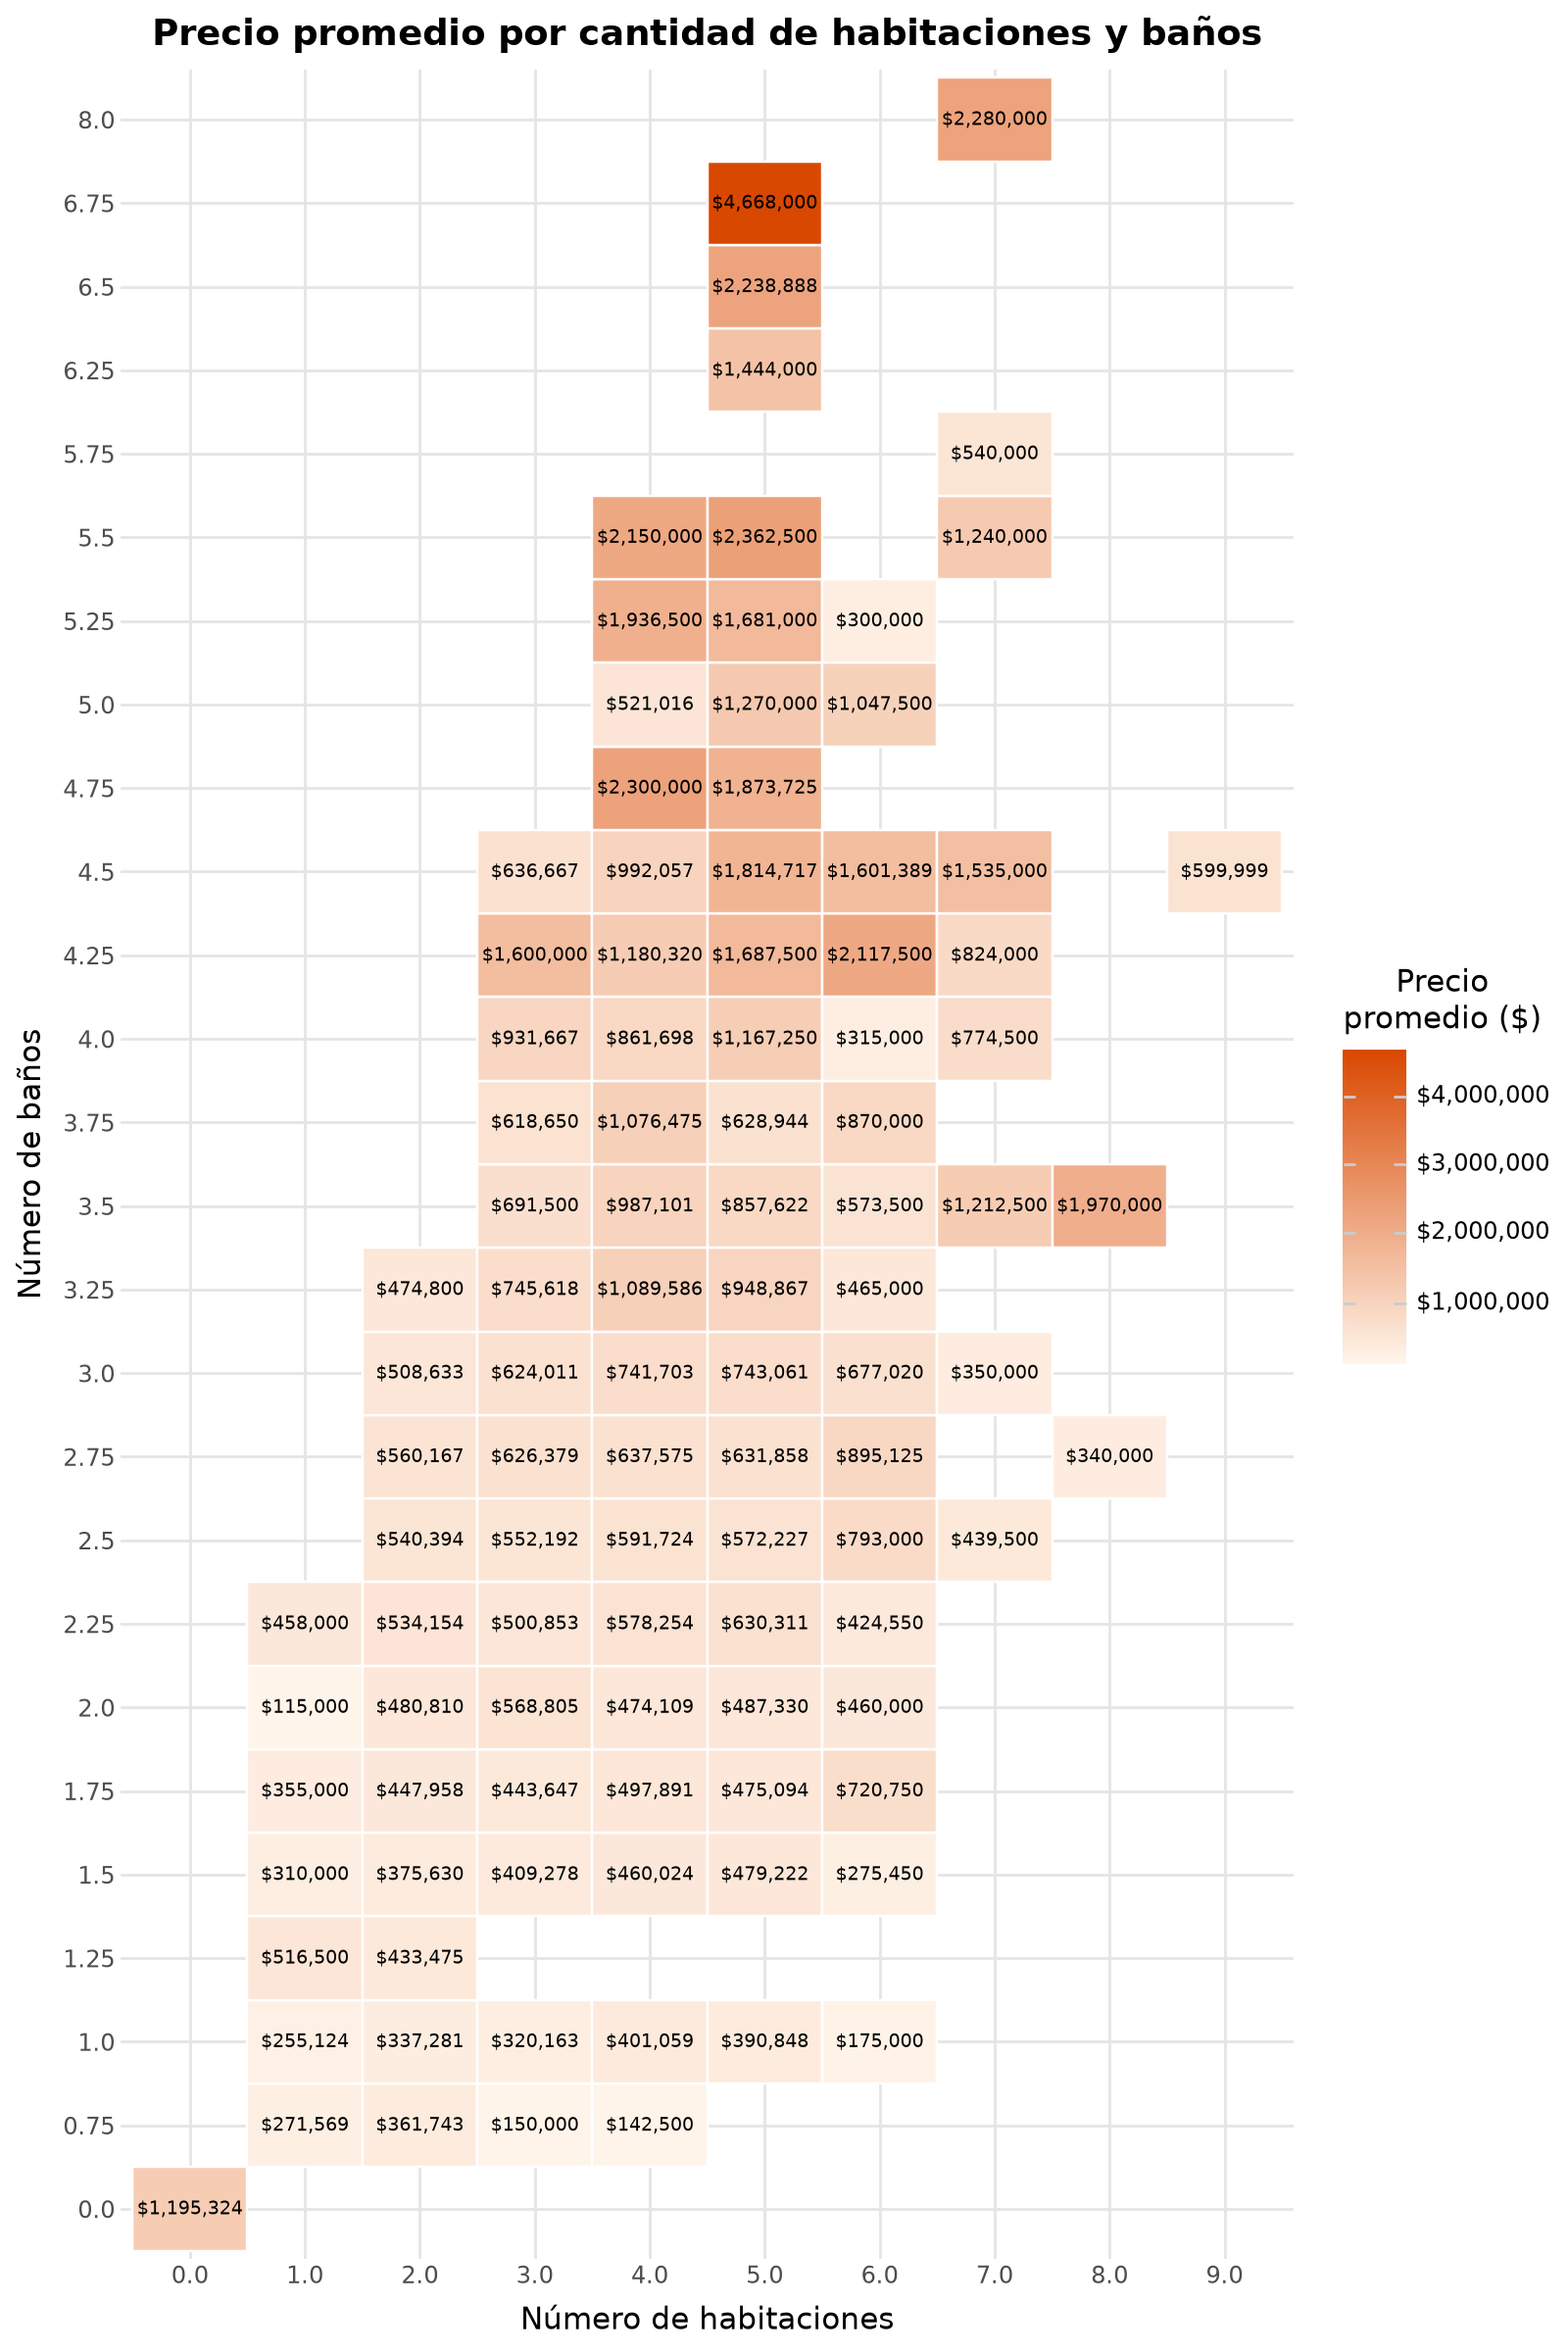

In [20]:
# heatmap de precio promedio por bedrooms y bathrooms

price_bed_bath = (df.groupby(['bedrooms', 'bathrooms'])['price']
                  .mean()
                  .reset_index())

display(price_bed_bath)

chart = (
    ggplot(price_bed_bath, aes(x='factor(bedrooms)', y='factor(bathrooms)', fill='price'))
    + geom_tile(color='white', size=0.5)
    + geom_text(aes(label='price.round(0).astype(int)'), size=7, color='black', format_string='${:,}')
    + scale_fill_gradient(
        low='#fff5eb', 
        high='#d94801', 
        name='Precio\npromedio ($)',
        labels=lambda l: [f'${int(v):,}' for v in l],
        limits=(price_bed_bath['price'].min(), price_bed_bath['price'].max())
    )
    + labs(
        title='Precio promedio por cantidad de habitaciones y baños',
        x='Número de habitaciones',
        y='Número de baños'
    )
    + theme_minimal()
    + theme(figure_size=(8, 12), plot_title=element_text(weight='bold'))
)

chart.show()

El heatmap anterior muestra la relación entre el número de cuartos (*bedrooms*) y baños (*bathrooms*) en una vivienda y su precio (*price*) promedio. Cada celda representa un conjunto específico de cuartos y baños, y contiene el precio (*price*) promedio de las viviendas y el gradiente del color correspondiente a dicho promedio.

Se observa que a medida que aumenta el número de cuartos y baños, el precio promedio también tiende a aumentar. Aunque hay algunas excepciones, como la vivienda con 0 cuartos y 0 baños, que tiene un precio promedio de $1,195,324, lo cual es un valor atípico. El número de habitaciones parece ser más influyente en el precio que el número de baños, ya que parece haber un aumento más consistente en el precio promedio a medida que aumenta el número de cuartos, mientras que el número de baños muestra una relación menos clara con el precio.

---

### Boxplots

#### Boxplot Price per sqft por Número de Floors

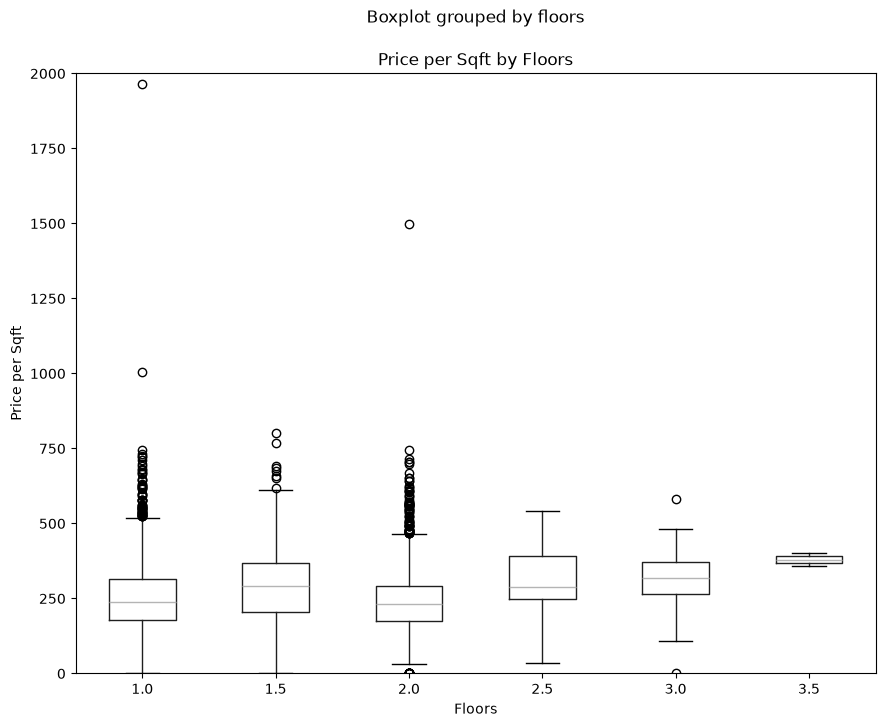

In [21]:
#boxplot of price per sqft by number of floors
df.boxplot(column='price_per_sqft', by='floors', grid=False, figsize=(10, 8))
plt.title('Price per Sqft by Floors')
plt.xlabel('Floors')
plt.ylim(0, 2000)
plt.ylabel('Price per Sqft')
plt.show()

Para este gráfico se agrupó price_per_sqft en base al número de pisos de una vivienda. Se acotó el rango de price_per_sqft debido a valores atípicos extremos (superando valores de hasta 20000) dificultaban la visualización de los datos.

**Hallazgos principales:**
- La mediana del precio por metro cuadrado muestra un ligero aumento mientras una vivienda poseyera más pisos.
- La mayoría de valores atípicos se concentran en las casas de 1 y 1.5 pisos, probablemente relacionado a otros factores como la zona en la que se encuentra.
- La caja de 3.5 pisos es la más compacta de todas, además de no contar con valores atípicos. Probablemente esto se deba a que hay pocos datos de viviendas en esta categoría.

Se observa el aumento de la mediana en relación a la cantidad de pisos de la viviendas, lo cual podría sugerir que el precio por metro cuadrado si podría verse influenciado según la cantidad de pisos. Aún así, hay que tratar con cuidado esta información debido a los pocos datos dentro de las categorias de 3 y 3.5 pisos.

#### Boxplot Price per sqft por City

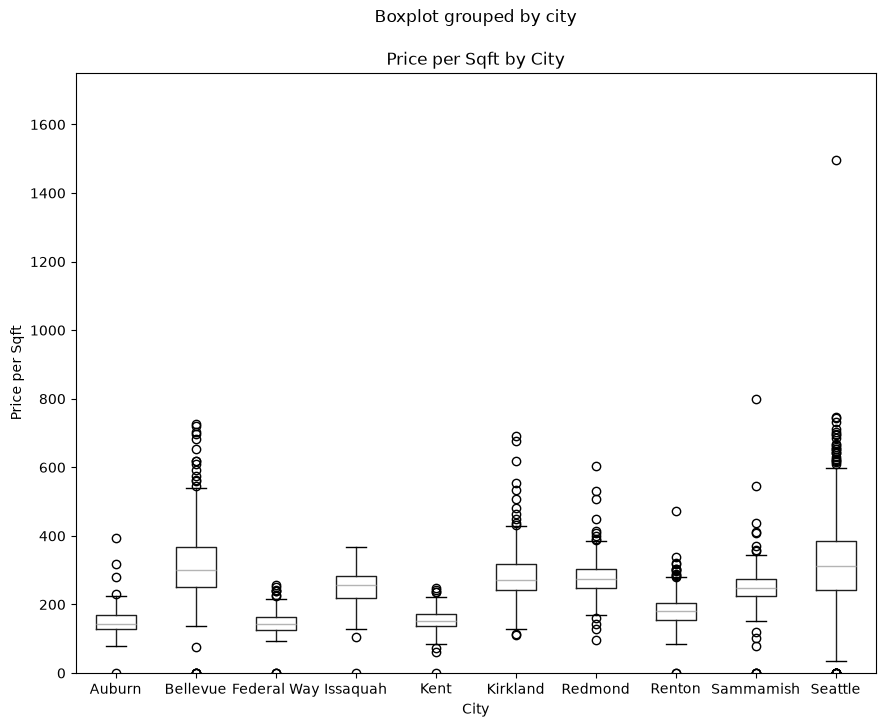

In [22]:
# boxplot of price per sqft by top 10 cities
cities = df['city'].value_counts().head(10).index
df_top = df[df['city'].isin(cities)]
df_top.boxplot(column='price_per_sqft', by='city', grid=False, figsize=(10, 8))
plt.title('Price per Sqft by City')
plt.xlabel('City')
plt.ylim(0, 1750)
plt.ylabel('Price per Sqft')
plt.show()


Para este gráfico, se agrupó el price_per_sqft en base al top 10 ciudades del dataset (city), para de esta manera comparar la distribución del precio por metro cuadrado de la vivienda según su ubicación. El rango de valores de price_per_sqft fue acotado debido a valores extremos (superiores a 5000 y a 20000) que distorsionaban la escala del gráfico y dificultaba la visualización del mismo.

**Hallazgos principales:**
- Se puede observar que los hogares mejor valorados por metro cuadrado están entre las ciudades de Seattle y Bellevue y Sammamish.
- Seattle y Bellevue son las ciudades que poseen más dispersión y valores atipicos. Esto podría deberse a la variabilidad de los precios segun la zona de dichas ciudades.
- Las ciudades más pequeñas como Kent o Auburn muestran cajas más compactas y consistentes.

**Conclusión:**
Con este boxplot podríamos considerar que la ubicación (city) es un factor relevante en la diferencia de precios por metro cuadrado de las viviendas, por lo que debería considerarse para análisis basados en el precio de viviendas.

### Gráfico de línea de precio promedio por pie cuadrado por año de construcción

Este tipo de gráfico fue tomado de [d3js.org](d3js.org)

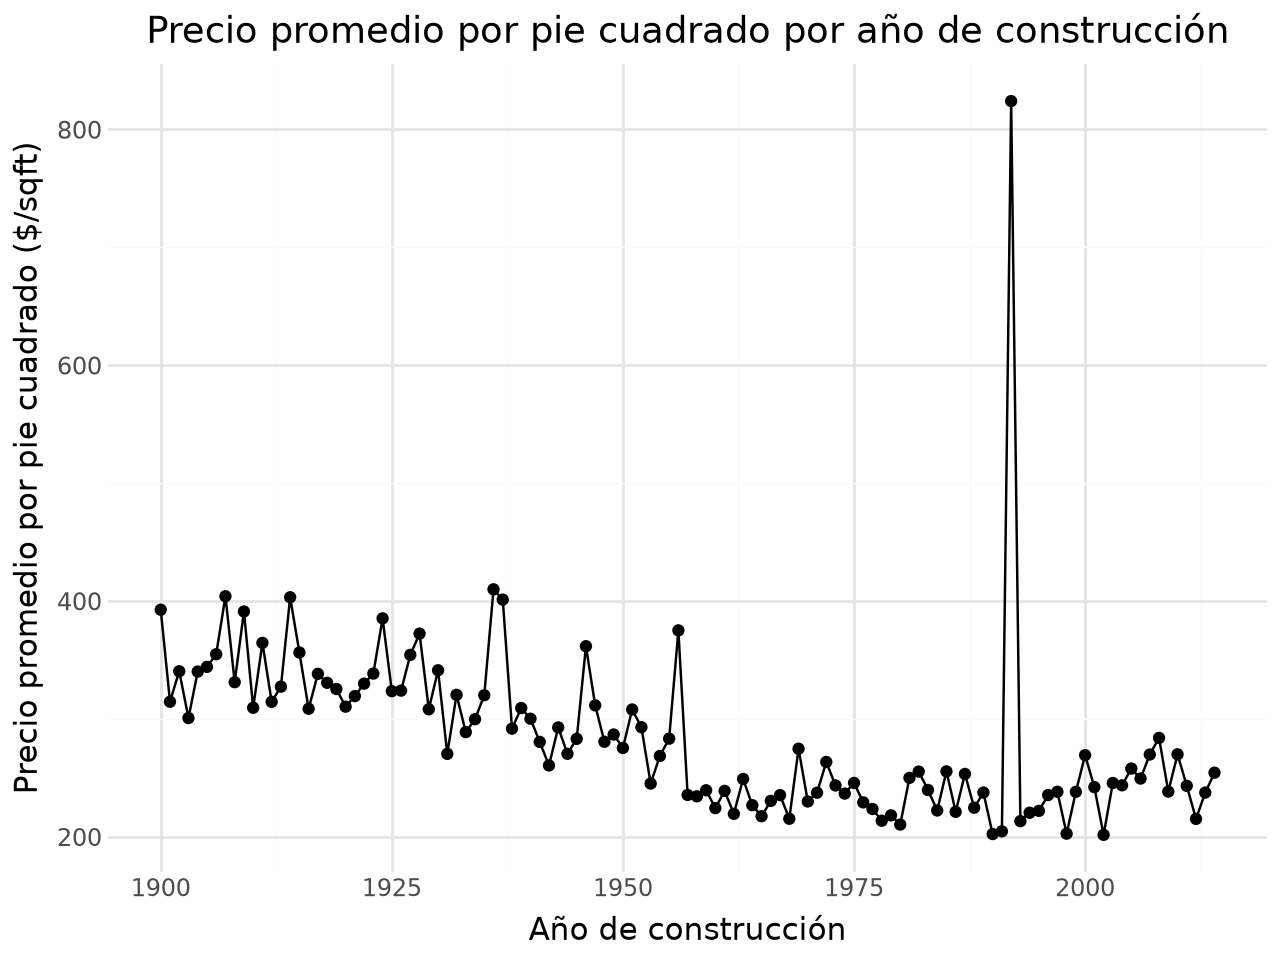

In [138]:
price_year = (df.groupby('yr_built')['price_per_sqft']
              .mean()
              .reset_index())

(
    ggplot(price_year, aes(x='yr_built', y='price_per_sqft')) 
    + geom_line() 
    + geom_point() 
    + labs(
        title='Precio promedio por pie cuadrado por año de construcción',
        x='Año de construcción',
        y='Precio promedio por pie cuadrado ($/sqft)') 
    + theme_minimal()
)

Este gráfico de líneas muestra el precio promedio por pie cuadrado de las viviendas en cada año en que fueron construidas. Cada punto en la línea representa el precio promedio de las viviendas en ese año específico. Se nota una tendencia general de disminución del precio promedio por pie cuadrado a medida que las viviendas son más nuevas, con 1 outlier, llevando a pensar que las viviendas mas antiguas se encuentran en mejores ubicaciones o son de mejor calidad, por el mayor precio.

## Conclusiones

A partir del análisis exploratorio se puede concluir que el precio de las viviendas no parece depender de una única característica, sino de la combinación de factores relacionados con el tamaño, la ubicación, la condición y otras características de la propiedad. La distribución de price presenta una asimetría hacia la derecha, debido a la presencia de viviendas con precios considerablemente altos. Esto también explica que la media del precio sea mayor que la mediana. Por esta razón, en análisis posteriores sería importante considerar el efecto de estos valores extremos e incluso evaluar una transformación logarítmica del precio.

El área habitable (sqft_living) muestra una relación positiva con el precio, por lo que podría ser una variable útil para explicar o predecir el valor de una vivienda. Sin embargo, la dispersión observada indica que viviendas de tamaños similares pueden presentar precios muy diferentes, por lo que el tamaño no es suficiente para explicar el precio por sí solo. Asimismo, variables como la cantidad de habitaciones presentan una correlación relativamente baja con el precio, lo que refuerza la necesidad de analizar varias características simultáneamente.

La matriz de correlaciones también permitió identificar variables que contienen información similar. En particular, sqft_living y sqft_above presentan una correlación de aproximadamente 0.88. Esto no significa que ambas sean poco relevantes, sino que incluirlas simultáneamente en determinados modelos podría aportar información redundante y generar problemas de multicolinealidad.

La ubicación parece ser uno de los factores más importantes del dataset. Se encontraron diferencias considerables tanto en el precio promedio de las viviendas como en el precio por pie cuadrado entre ciudades. Ciudades como Clyde Hill, Mercer Island, Yarrow Point y Medina presentan precios promedio elevados, mientras que Seattle y Bellevue destacan en el precio por pie cuadrado y muestran una mayor variabilidad. Esto sugiere que la variable city debería ser considerada en cualquier análisis posterior orientado a explicar o predecir precios.

Por otra parte, características como la condición, el número de pisos, habitaciones y baños muestran ciertas diferencias en los precios, pero sus relaciones no son completamente consistentes. En algunos grupos existen pocas observaciones o valores atípicos que pueden provocar promedios poco representativos. Por esta razón, sería conveniente analizar también la cantidad de observaciones de cada categoría.

El año de construcción también presenta una relación interesante con el precio por pie cuadrado, observándose una tendencia general a que las viviendas más antiguas tengan un mayor precio por unidad de área. Sin embargo, este resultado no necesariamente significa que la antigüedad aumente el valor de una propiedad, ya que podría estar relacionado con otras variables, como la ubicación de las viviendas antiguas, renovaciones u otras características.

En conjunto, este EDA permite plantear como siguiente paso un experimento de modelado predictivo del precio de las viviendas (regresión). Se podrían comparar modelos utilizando variables relacionadas con ubicación, tamaño, condición, antigüedad, habitaciones y baños para determinar cuáles aportan mayor capacidad predictiva (mejoran la R). También sería recomendable tratar los valores atípicos y evitar incluir variables altamente redundantes sin evaluar previamente su efecto.

Un detalle a clarificar es que como el dataset es sobre datos observacionales de transacciones y no de un muestreo controlado, estos resultados permiten encontrar asociaciones y generar hipótesis, pero no afirmar que una característica determinada sea la causa de un aumento o disminución en el precio.

## Referencias

lalit7881, (s.f.). House Price Prediction. Kaggle. https://www.kaggle.com/code/lalit7881/house-price-prediction.

D3, (s.f.). Gráfico de líneas. https://d3js.org/d3-shape/line